In [30]:
import os
import sys
current_dir = os.getcwd()
root_path = os.path.abspath(os.path.join(current_dir, '..', '..'))
if root_path not in sys.path:
    sys.path.append(root_path)
import torch
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import torch.nn as nn
import numpy as np
import pickle
import pandas as pd
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import math
import scipy.special
import random as rd
import matplotlib.pyplot as plt
import torch.nn.functional as F
import torchvision.models as models
from torchvision.models import VGG16_Weights
from tqdm import tqdm
import torch.optim.lr_scheduler as lr_scheduler
from python_scripts.sgp_utils import *
from python_scripts.plotting import *
from scipy.special import gammaln
import warnings
warnings.filterwarnings("ignore")
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 150

print("GPU Available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))

GPU Available: True
GPU Name: NVIDIA GeForce RTX 4060


#### Choose the dataset you want to use :
* must be data the model did not see at training
* first column : __y_true__ $\in \{0,1\}$ are the samples labels  
* second column : __y_pred__ are the predicted class of samples ($\in \{0,1\}$ too)
* third column : __kappa_f__ is confidence function for each sample, $\in \mathbb{R}$

In [31]:
sgp_df = pickle.load(open('sgp_set_resnet','rb')) 
print(sgp_df.shape)
print('Propotion of 1s: ', np.round(sgp_df.y_true.sum()/sgp_df.shape[0],2))
sgp_df.head() 

(40000, 3)
Propotion of 1s:  0.1


,y_true,y_pred,kappa
0,0.0,0.0,0.999986
1,0.0,0.0,0.999986
2,0.0,0.0,0.999990
3,0.0,0.0,0.999980
4,0.0,0.0,0.999816


In [32]:
delta = 0.005 # = 1 - probability that the metric be controlled by the bound
greedy_search_steps_num = 50 # number of theta confidence thresholds considered during the greedy search. For Softmax Response it splits [0.5, 1] into greedy_search_steps_num intervals
num_targets = 100 # number of targets r* to consider when drawing metric/coverage of metric/theta curves

In [33]:
train_set = sgp_df.iloc[:3*int(len(sgp_df)/4)] # set that will be used to derive the bounds
train_set = train_set.sort_values('kappa', ascending=True).reset_index(drop=True).copy() # we sort by confidence function, as specified in Algorithms 1-2
test_set = sgp_df.iloc[3*int(len(sgp_df)/4):] # set that will be used to test the bounds computed on train_set

Plot lines config

In [34]:
# this fist lines list is with respect to THETA: we plot metric targets, metric bound, metric computed on train_set, metric computed on test_set
lines_list_theta = [{'kappa':'SR','name':'Target', 'colname':'metric_target','x_axis':'theta_star','x_axis_name':r'$\theta$','colour':'#d51414','style':'-'},
                    {'kappa':'SR','name':'Guaranteed', 'colname':'metric_bound','x_axis':'theta_star','x_axis_name':r'$\theta$','colour':'#1d3ae2','style':'--'},
                    {'kappa':'SR','name':'On train set', 'colname':'train_metric','x_axis':'theta_star','x_axis_name':r'$\theta$','colour':"#8F7A1C",'style':'--'},
                    {'kappa':'SR','name':'On test set', 'colname':'test_metric','x_axis':'theta_star','x_axis_name':r'$\theta$','colour':"#0f770a",'style':'-'}]
# this lines list is the same, only with respect to COVERAGE (strictly decreasing function of theta):
lines_list_coverage = [{'kappa':'SR','name':'Target', 'colname':'metric_target','x_axis':'test_coverage','x_axis_name':'Coverage','colour':'#d51414','style':'-'},
                       {'kappa':'SR','name':'Guaranteed', 'colname':'metric_bound','x_axis':'test_coverage','x_axis_name':'Coverage','colour':'#1d3ae2','style':'--'},
                       {'kappa':'SR','name':'On train set', 'colname':'train_metric','x_axis':'train_coverage','x_axis_name':'Coverage','colour':'#8F7A1C','style':'--'},
                       {'kappa':'SR','name':'On test set', 'colname':'test_metric','x_axis':'test_coverage','x_axis_name':'Coverage','colour':'#0f770a','style':'-'}]

## <font color = 'orange'> 1. __Unconditional risks__
Dichotomy search for upper bound

### <font color = 'orange'> 1.1. __0/1 risk__

In [35]:
# we restricted to [0.0001,0.02] after checking the bounds in joint_control_resnet.ipynb ; without prior knowledge just search over [0,1] with a higher num_targets
metric_targets=np.linspace(0.0001,0.02,num=num_targets)

Curves w.r.t. $\theta$, using Softmax Response (SR) as confidence function

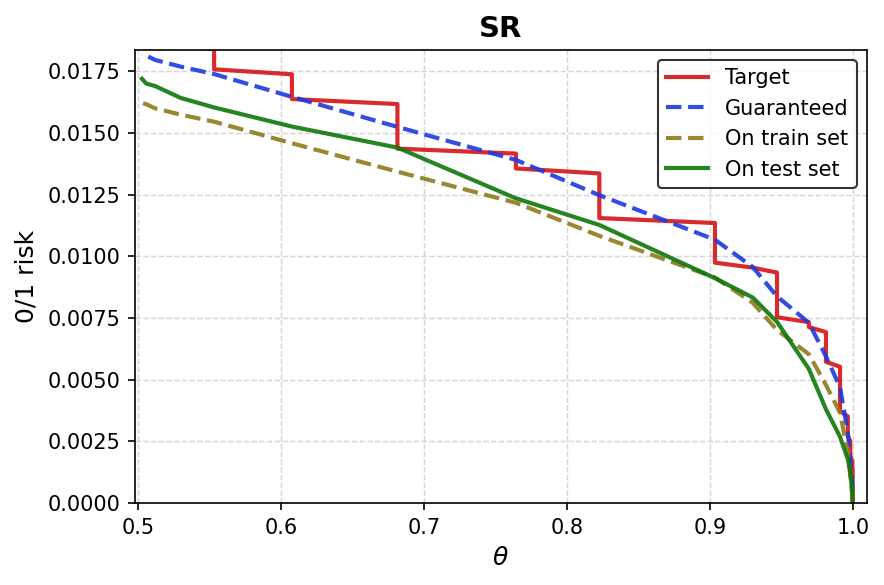

In [36]:
results = sgp_at_targets(train_set, test_set,
                         delta=delta, metric_targets=metric_targets, mode='dicho')
all_results = {'SR':results, 'MCD':None}

metric_plots(all_results, metric='0/1 risk', 
             lines_list=lines_list_theta,
             xlim=[0.99*min(results.theta_star),1.01*max(results.theta_star)], 
             ylim=[0.99*min(min(results.test_metric), min(results.train_metric)), 1.01*max(results.metric_bound)],
             title='SR')

Curves w.r.t. coverage, using Softmax Response (SR) as confidence function

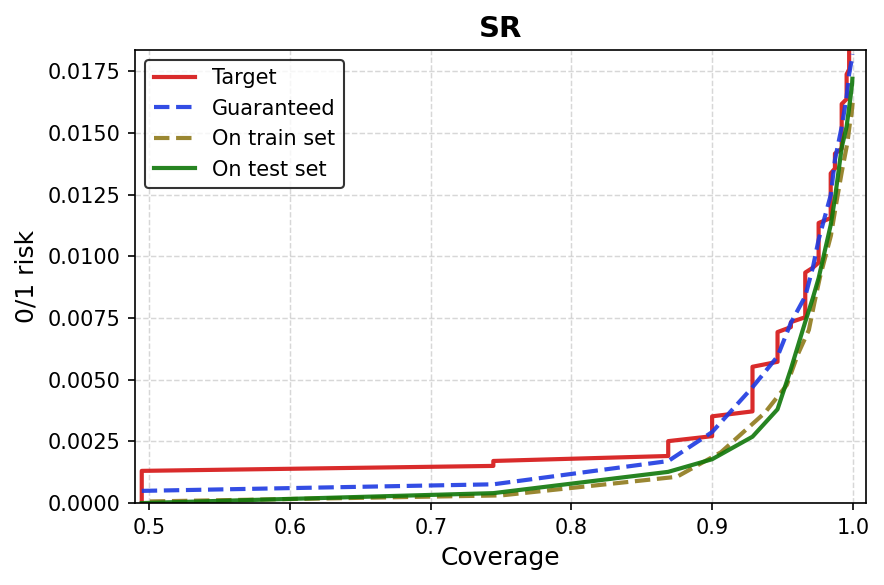

In [37]:
metric_plots(all_results, metric='0/1 risk', 
             lines_list=lines_list_coverage,
             xlim=[0.99*min(results.test_coverage),1.01*max(results.test_coverage)], 
             ylim=[0.99*min(min(results.test_metric), min(results.train_metric)), 1.01*max(results.metric_bound)],
             title='SR')

### <font color = 'orange'> 1.2. __FP risk__

In [38]:
metric_targets=np.linspace(0.0001,0.0035,num=num_targets)

Curves w.r.t. $\theta$, using Softmax Response (SR) as confidence function

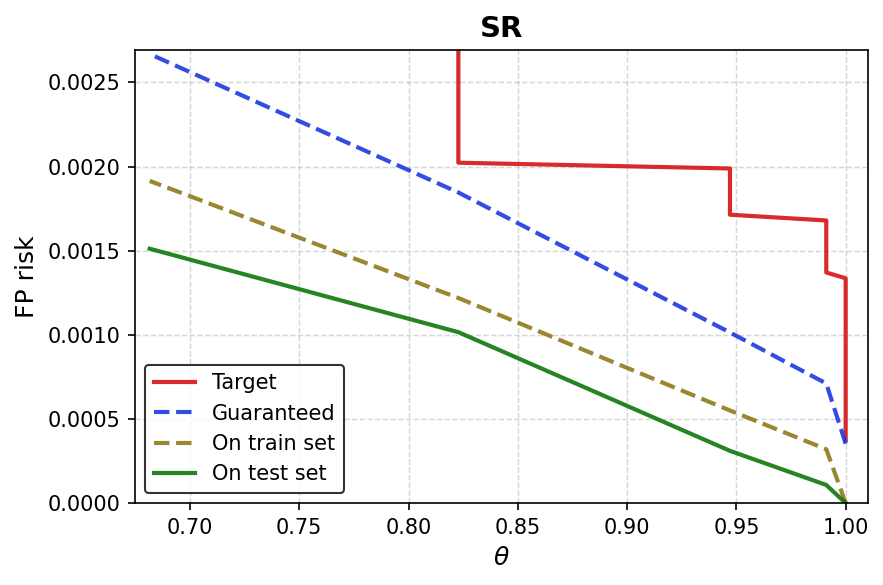

In [39]:
results = sgp_at_targets(train_set, test_set,
                         delta=delta, metric_targets=metric_targets, mode='dicho',
                         metric='FP')
all_results = {'SR':results, 'MCD':None}

metric_plots(all_results, metric='FP risk', 
             lines_list=lines_list_theta,
             xlim=[0.99*min(results.theta_star),1.01*max(results.theta_star)], 
             ylim=[0.99*min(min(results.test_metric), min(results.train_metric)), 1.01*max(results.metric_bound)],
             title='SR')

Curves w.r.t. coverage, using Softmax Response (SR) as confidence function

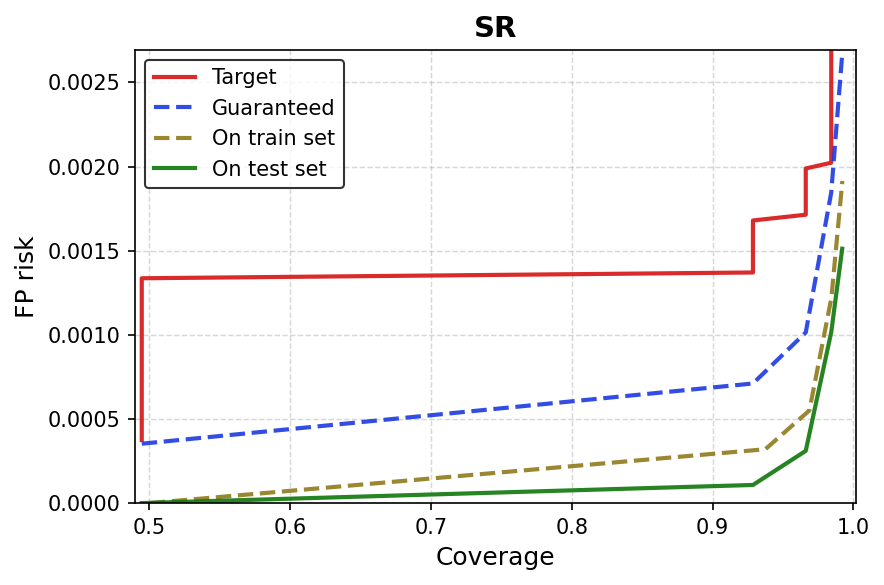

In [40]:
metric_plots(all_results, metric='FP risk', 
             lines_list=lines_list_coverage,
             xlim=[0.99*min(results.test_coverage),1.01*max(results.test_coverage)], 
             ylim=[0.99*min(min(results.test_metric), min(results.train_metric)), 1.01*max(results.metric_bound)],
             title='SR')

### <font color = 'orange'> 1.3. __FN risk__

In [41]:
metric_targets=np.linspace(0.0001,0.025,num=num_targets) # determine them by looking at metric evolution w.r.t. \theta :) cf. joint_control ntebooks

Curves w.r.t. $\theta$, using Softmax Response (SR) as confidence function

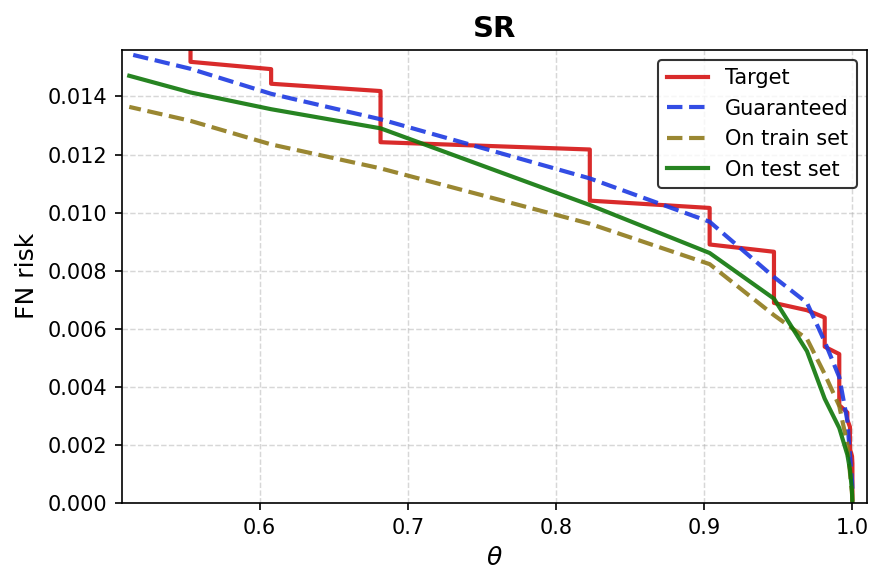

In [42]:
results = sgp_at_targets(train_set, test_set,
                         delta=delta, metric_targets=metric_targets, mode='dicho',
                         metric='FN')
all_results = {'SR':results, 'MCD':None}

metric_plots(all_results, metric='FN risk', 
             lines_list=lines_list_theta,
             xlim=[0.99*min(results.theta_star),1.01*max(results.theta_star)], 
             ylim=[0.99*min(min(results.test_metric), min(results.train_metric)), 1.01*max(results.metric_bound)],
             title='SR')

Curves w.r.t. coverage, using Softmax Response (SR) as confidence function

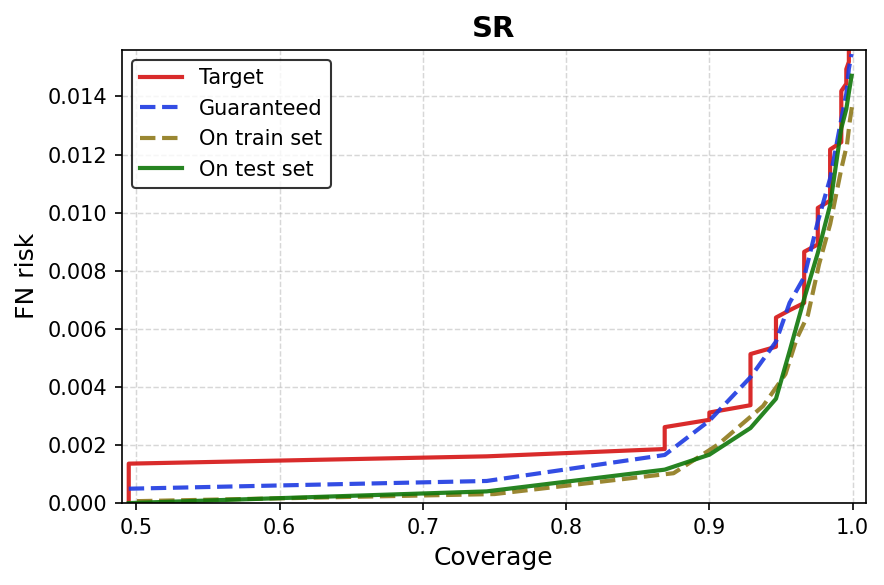

In [43]:
metric_plots(all_results, metric='FN risk', 
             lines_list=lines_list_coverage,
             xlim=[0.99*min(results.test_coverage),1.01*max(results.test_coverage)], 
             ylim=[0.99*min(min(results.test_metric), min(results.train_metric)), 1.01*max(results.metric_bound)],
             title='SR')

## <font color = 'orange'> __2. Conditional metrics__
Greedy search for the bounds

### <font color = 'orange'> 2.1. __FPR__

In [44]:
metric_targets=np.linspace(0.0001,0.0035,num=num_targets) # determine them by looking at metric evolution w.r.t. \theta :) cf. joint_control ntebooks

Curves w.r.t. $\theta$, using Softmax Response (SR) as confidence function

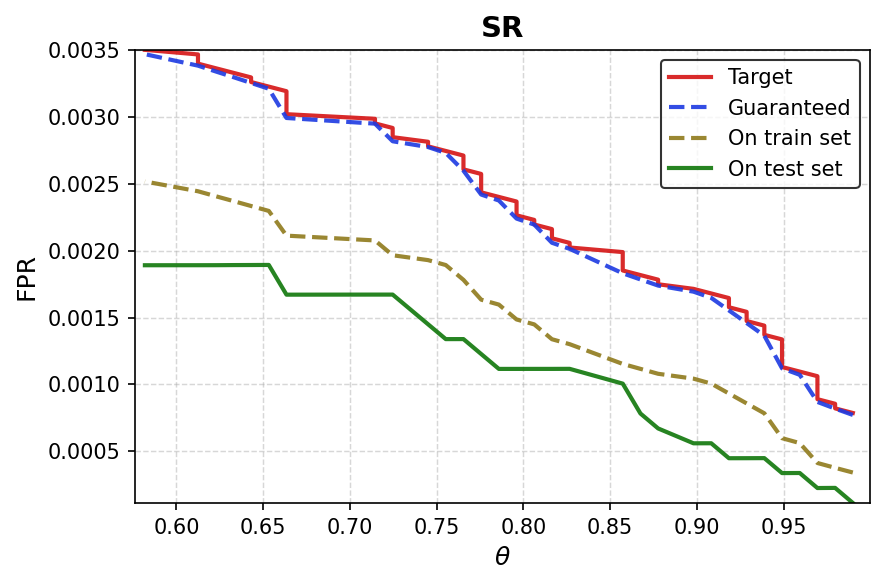

In [45]:
results = sgp_at_targets(train_set, test_set,
                         delta=delta, metric_targets=metric_targets,
                         mode='greedy', steps=greedy_search_steps_num,
                         metric='FPR')
all_results = {'SR':results, 'MCD':None}

metric_plots(all_results, metric='FPR', 
             lines_list=lines_list_theta,
             xlim=[0.99*min(results.theta_star),1.01*max(results.theta_star)], 
             ylim=[0.99*min(min(results.test_metric), min(results.train_metric)), 1.01*max(results.metric_bound)],
             title='SR')

Curves w.r.t. coverage, using Softmax Response (SR) as confidence function

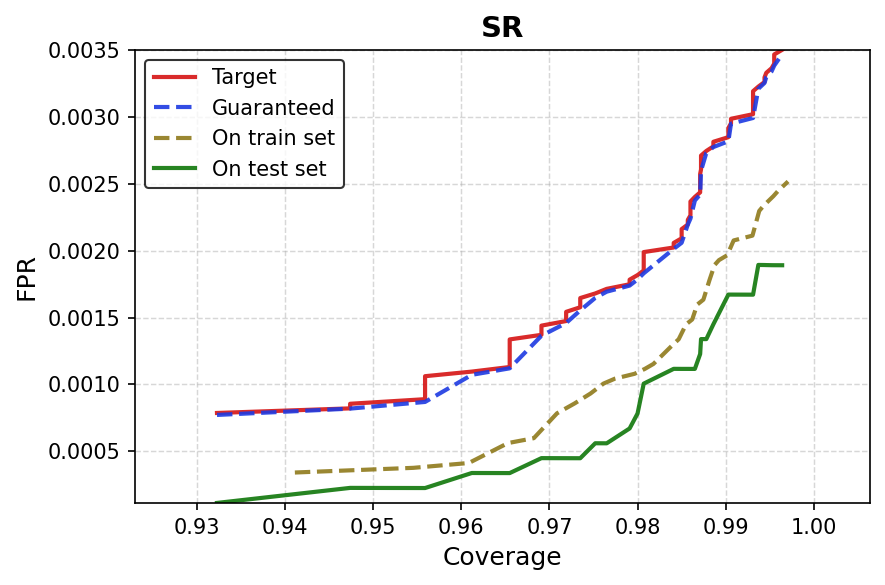

In [46]:
metric_plots(all_results, metric='FPR', 
             lines_list=lines_list_coverage,
             xlim=[0.99*min(results.test_coverage),1.01*max(results.test_coverage)], 
             ylim=[0.99*min(min(results.test_metric), min(results.train_metric)), 1.01*max(results.metric_bound)],
             title='SR')

### <font color = 'orange'> 2.2. __FNR__

In [47]:
metric_targets=np.linspace(0.03,0.2,num=num_targets) # determine them by looking at metric evolution w.r.t. \theta :) cf. joint_control ntebooks

Curves w.r.t. $\theta$, using Softmax Response (SR) as confidence function

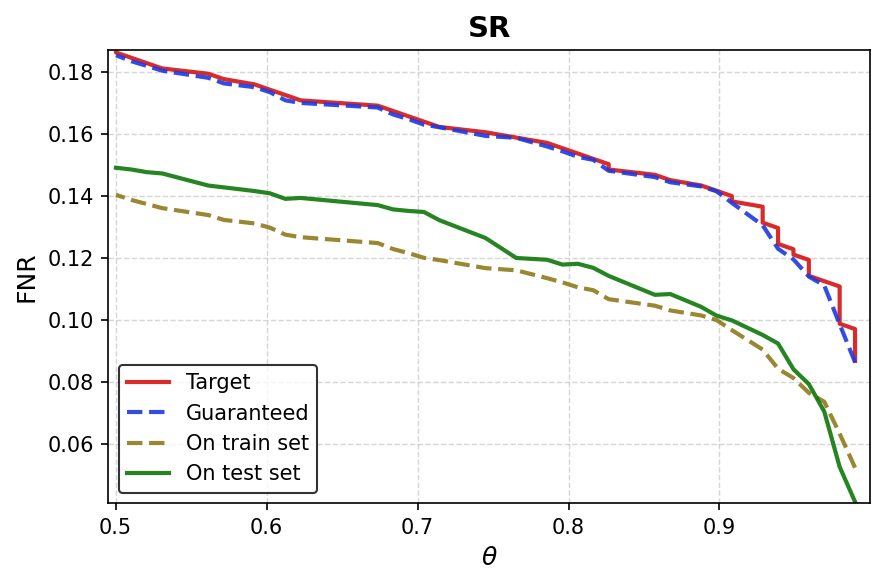

In [48]:
results = sgp_at_targets(train_set, test_set,
                         delta=delta, metric_targets=metric_targets,
                         mode='greedy', steps=greedy_search_steps_num,
                         metric='FNR')
all_results = {'SR':results, 'MCD':None}

metric_plots(all_results, metric='FNR', 
             lines_list=lines_list_theta,
             xlim=[0.99*min(results.theta_star),1.01*max(results.theta_star)], 
             ylim=[0.99*min(min(results.test_metric), min(results.train_metric)), 1.01*max(results.metric_bound)],
             title='SR')

Curves w.r.t. coverage, using Softmax Response (SR) as confidence function

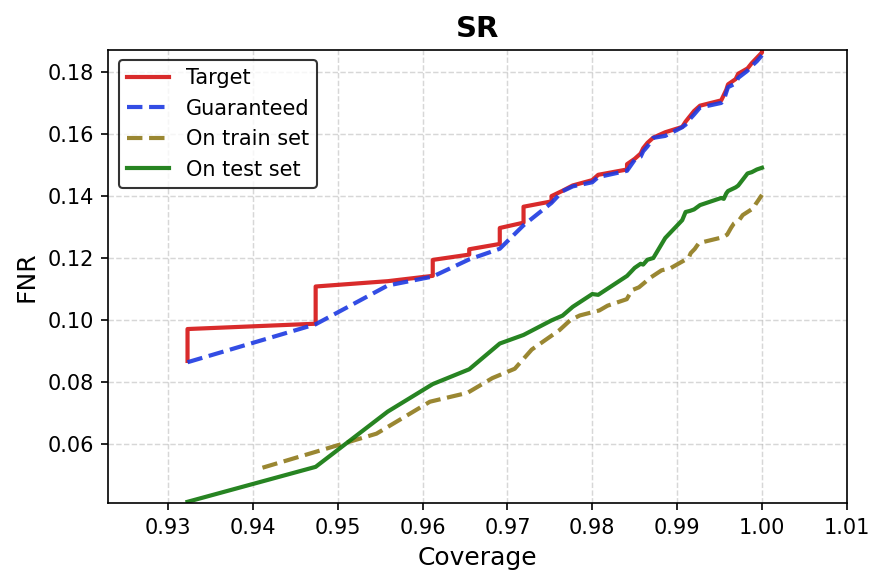

In [49]:
metric_plots(all_results, metric='FNR', 
             lines_list=lines_list_coverage,
             xlim=[0.99*min(results.test_coverage),1.01*max(results.test_coverage)], 
             ylim=[0.99*min(min(results.test_metric), min(results.train_metric)), 1.01*max(results.metric_bound)],
             title='SR')

### <font color = 'orange'> 2.3. __PPV__

In [50]:
metric_targets=np.linspace(0.95,0.999,num=num_targets) # determine them by looking at metric evolution w.r.t. \theta :) cf. joint_control ntebooks

Curves w.r.t. $\theta$, using Softmax Response (SR) as confidence function

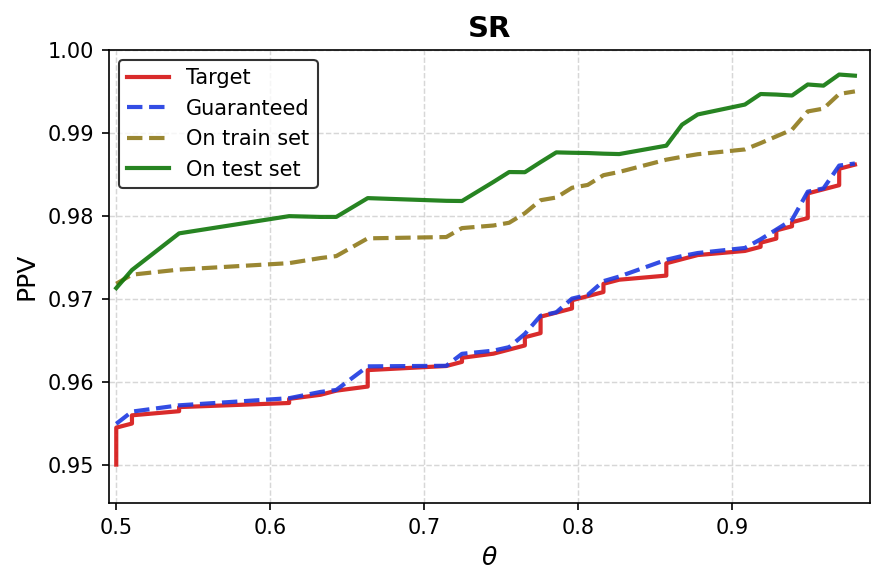

In [51]:
results = sgp_at_targets(train_set, test_set,
                         delta=delta, metric_targets=metric_targets,
                         mode='greedy', steps=greedy_search_steps_num,
                         metric='PPV')
all_results = {'SR':results, 'MCD':None}

metric_plots(all_results, metric='PPV', 
             lines_list=lines_list_theta,
             xlim=[0.99*min(results.theta_star),1.01*max(results.theta_star)], 
             ylim=[0.99*min(results.metric_bound), 
                   min(1,1.01*max(max(results.train_metric),max(results.test_metric)))],
             title='SR')

Curves w.r.t. coverage, using Softmax Response (SR) as confidence function

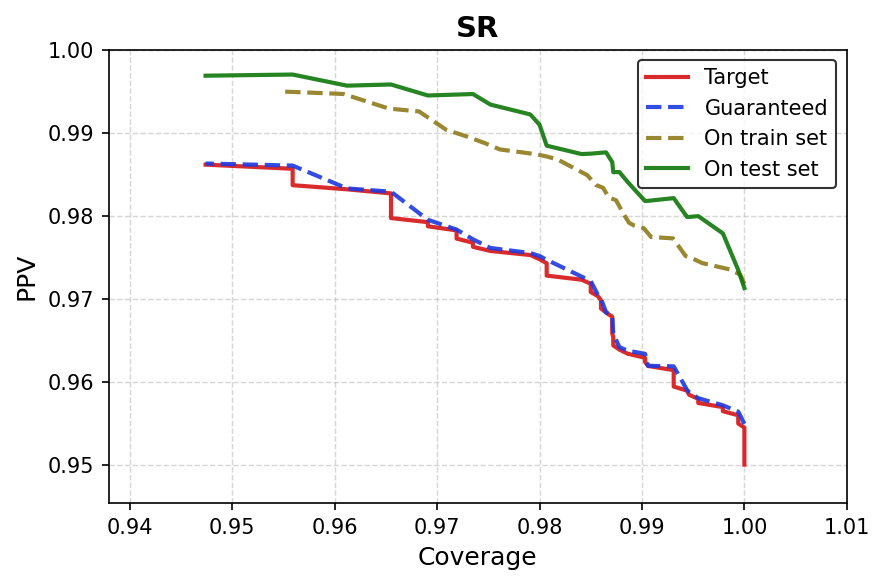

In [52]:
metric_plots(all_results, metric='PPV', 
             lines_list=lines_list_coverage,
             xlim=[0.99*min(results.test_coverage),1.01*max(results.test_coverage)], 
             ylim=[0.99*min(results.metric_bound), 
                   min(1,1.01*max(max(results.train_metric),max(results.test_metric)))],
             title='SR')

### <font color = 'orange'> 2.4. __SE__

In [53]:
metric_targets=np.linspace(0.84,0.96,num=num_targets) # determine them by looking at metric evolution w.r.t. \theta :) cf. joint_control ntebooks

Curves w.r.t. $\theta$, using Softmax Response (SR) as confidence function

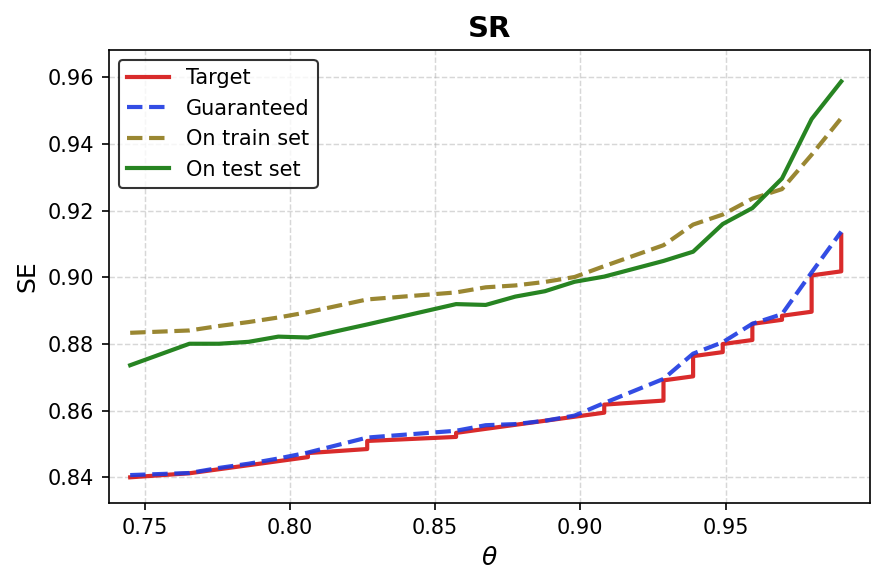

In [54]:
results = sgp_at_targets(train_set, test_set,
                         delta=delta, metric_targets=metric_targets,
                         mode='greedy', steps=greedy_search_steps_num,
                         metric='SE')
all_results = {'SR':results, 'MCD':None}

metric_plots(all_results, metric='SE', 
             lines_list=lines_list_theta,
             xlim=[0.99*min(results.theta_star),1.01*max(results.theta_star)], 
             ylim=[0.99*min(results.metric_bound), 
                   min(1,1.01*max(max(results.train_metric),max(results.test_metric)))],
             title='SR')

Curves w.r.t. coverage, using Softmax Response (SR) as confidence function

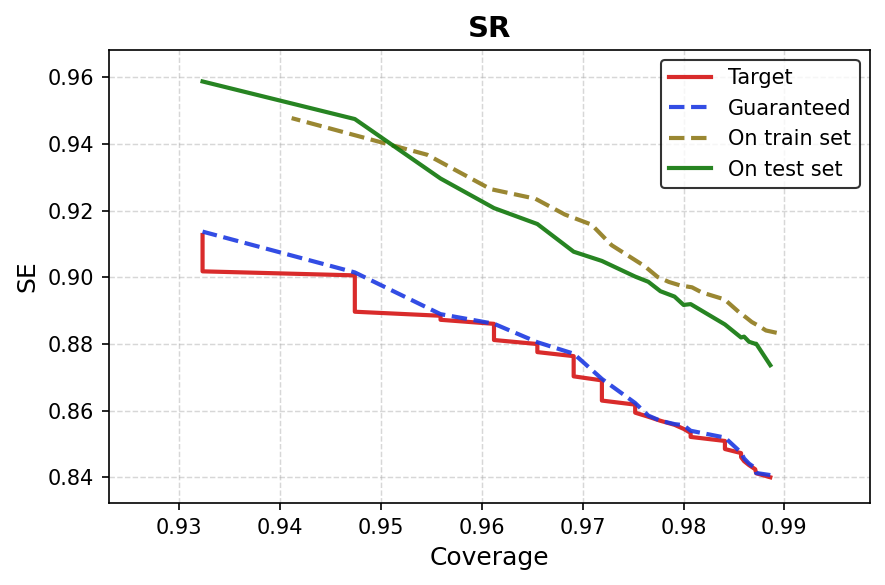

In [55]:
metric_plots(all_results, metric='SE', 
             lines_list=lines_list_coverage,
             xlim=[0.99*min(results.test_coverage),1.01*max(results.test_coverage)], 
             ylim=[0.99*min(results.metric_bound), 
                   min(1,1.01*max(max(results.train_metric),max(results.test_metric)))],
             title='SR')

### <font color = 'orange'> 2.5. __SP__

In [56]:
metric_targets=np.linspace(0.99,0.9999,num=num_targets) # determine them by looking at metric evolution w.r.t. \theta :) cf. joint_control ntebooks

Curves w.r.t. $\theta$, using Softmax Response (SR) as confidence function

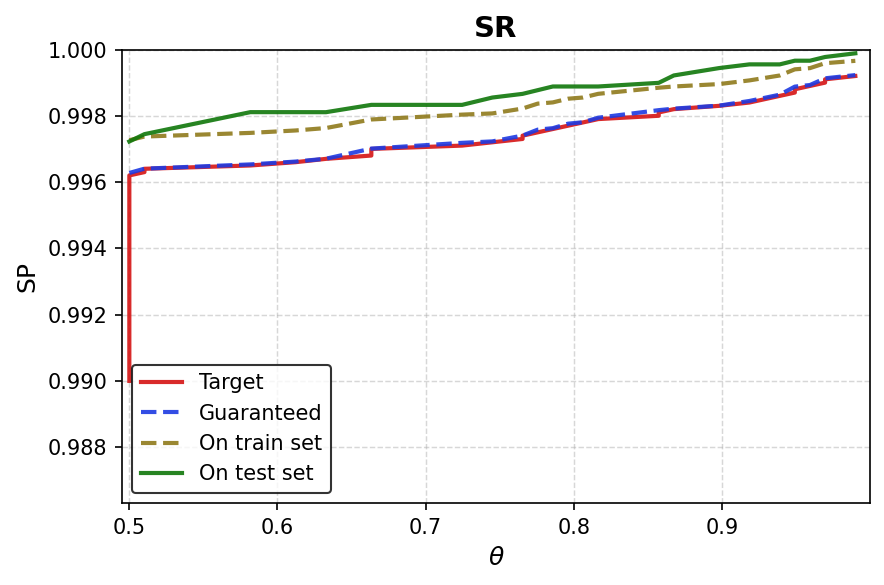

In [57]:
results = sgp_at_targets(train_set, test_set,
                         delta=delta, metric_targets=metric_targets,
                         mode='greedy', steps=greedy_search_steps_num,
                         metric='SP')
all_results = {'SR':results, 'MCD':None}

metric_plots(all_results, metric='SP', 
             lines_list=lines_list_theta,
             xlim=[0.99*min(results.theta_star),1.01*max(results.theta_star)], 
             ylim=[0.99*min(results.metric_bound), 
                   min(1,1.01*max(max(results.train_metric),max(results.test_metric)))],
             title='SR')

Curves w.r.t. coverage, using Softmax Response (SR) as confidence function

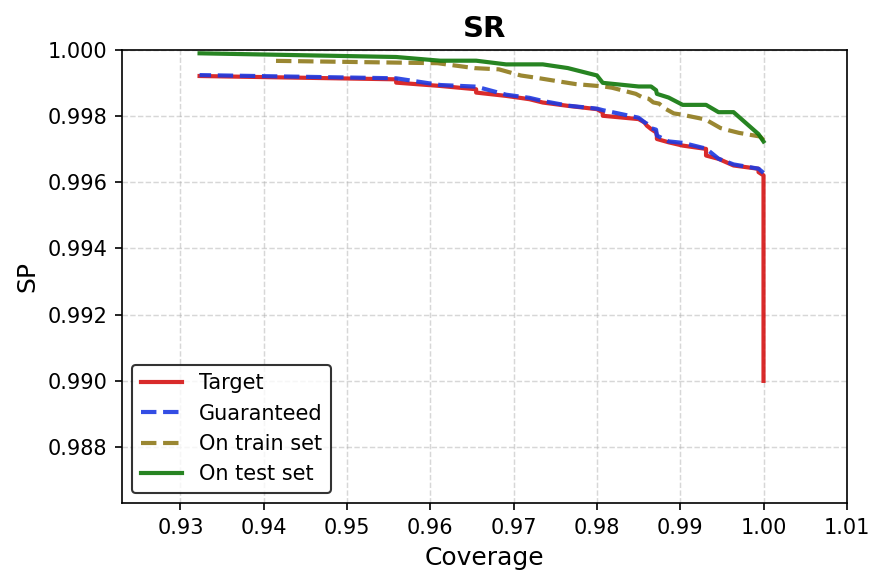

In [58]:
metric_plots(all_results, metric='SP', 
             lines_list=lines_list_coverage,
             xlim=[0.99*min(results.test_coverage),1.01*max(results.test_coverage)], 
             ylim=[0.99*min(results.metric_bound), 
                   min(1,1.01*max(max(results.train_metric),max(results.test_metric)))],
             title='SR')